In [2]:
# imports

import time
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

In [3]:
# find h5 files

file_path = r"G:\Shared drives\XPCS_2026\data\FCGT_06-22-26"

h5_files = sorted([
    os.path.join(file_path, f)
    for f in os.listdir(file_path)
    if f.lower().endswith((".h5", ".hdf5"))
])

print("Number of h5 files found:", len(h5_files))
print()

for i, f in enumerate(h5_files):
    print(f"{i:3d} : {os.path.basename(f)}")

Number of h5 files found: 12

  0 : 013_FCGT_1D_yscan_bf14adfb-bdf6-4e07-8189-d08802181949.h5
  1 : 014_FCGT_XPCS_temparray_low_44268b63-5805-43bf-bf74-74c7aa4db5f1.h5
  2 : 015_FCGT_XPCS_temparray_SpeckleDisappearance_f73301b1-3bf4-483c-9592-996f3bc76305.h5
  3 : 016_FCGT_cool_to_62a9f25d-fc5e-4a43-817d-b8da260b31fc.h5
  4 : 017_FCGT_translate_260K_y1290_f0f5289b-0f68-451b-b6fb-7179ac875e40.h5
  5 : 018_FCGT_translate_250K_y1295_5ed495bc-a7c7-4bbd-b704-159081b44c63.h5
  6 : 019_FCGT_translate_250K_y1300_5e9a8560-9d87-4f2f-bc62-a6d00009ff6b.h5
  7 : 020_FCGT_translate_250K_y1285_00cc873c-e14b-46a1-88c5-cde794c11f22.h5
  8 : 021_FCGT_translate_250K_y1280_92356fbc-2523-4476-bca4-13444c41a11f.h5
  9 : 023_FCGT_HeatingUp_26f1e84b-bc40-4915-861a-97aa586b168e.h5
 10 : 029_FCGT_temp_array_320K_55eb452f-b467-47cb-a3a2-cbf1c11b2f68.h5
 11 : 031_FCGT_Temp_Array_XPCS_2347bf69-2770-41e2-bd6e-515d6eb30320.h5


In [4]:
# choose file by index

file_index = 1   # index chosen here, change to look at a different file

file = h5_files[file_index]

print("Chosen file:")
print(file)

Chosen file:
G:\Shared drives\XPCS_2026\data\FCGT_06-22-26\014_FCGT_XPCS_temparray_low_44268b63-5805-43bf-bf74-74c7aa4db5f1.h5


In [5]:
# open h5 data

dataset_path = "entry1/instrument_1/detector_1/data"

with h5py.File(file, "r") as f:
    dset = f[dataset_path]
    print("Dataset shape:", dset.shape)
    print("Dataset dtype:", dset.dtype)

Dataset shape: (4, 2500, 595, 633)
Dataset dtype: uint16


In [6]:
# load one frame

frame_number = 300   # change this if needed

with h5py.File(file, "r") as f:
    data = f[dataset_path]

    if data.ndim == 4:
        frame = data[0, frame_number, :, :]
    elif data.ndim == 3:
        frame = data[frame_number, :, :]
    elif data.ndim == 2:
        frame = data[:, :]
    else:
        raise ValueError(f"Unexpected data shape: {data.shape}")

frame = frame.astype(float)

print("Frame shape:", frame.shape)
print("Min:", np.nanmin(frame))
print("Max:", np.nanmax(frame))

Frame shape: (595, 633)
Min: 660.0
Max: 65535.0


In [7]:
# find center from smoothed intensity

img = frame.copy()

img_smooth = gaussian_filter(img, sigma=3)

# ignore bad values
img_smooth[~np.isfinite(img_smooth)] = 0

cy, cx = np.unravel_index(
    np.argmax(img_smooth),
    img_smooth.shape
)
cy,cx = 325,320

print("Estimated center:")
print("x =", cx)
print("y =", cy)

Estimated center:
x = 320
y = 325


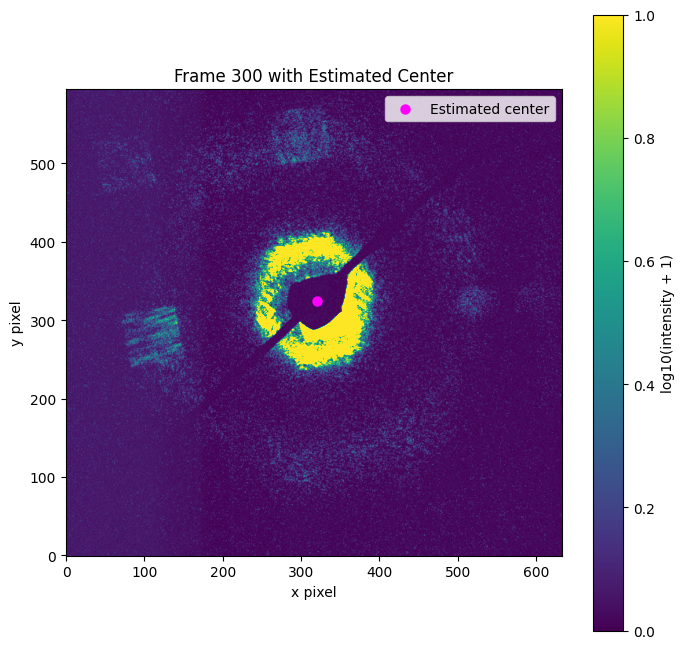

In [8]:
# plot center overlay (brighter contrast)

display_img = np.log10(frame + 1)

plt.figure(figsize=(8, 8))

plt.imshow(
    display_img,
    origin="lower",
    cmap="viridis",
    vmin=np.percentile(display_img, 5),    # darker background clipped
    vmax=np.percentile(display_img, 98)  # brightest 0.5% clipped
)

plt.scatter(
    cx, cy,
    s=30,
    marker="o",
    color="magenta",
    linewidths=2,
    label="Estimated center"
)

plt.colorbar(label="log10(intensity + 1)")
plt.title(f"Frame {frame_number} with Estimated Center")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.legend()
plt.show()

In [9]:
# manually adjust center if needed

cx_manual = cx
cy_manual = cy

# example:
# cx_manual = 298
# cy_manual = 301

cx = cx_manual
cy = cy_manual

print("Using center:")
print("x =", cx)
print("y =", cy)

Using center:
x = 320
y = 325


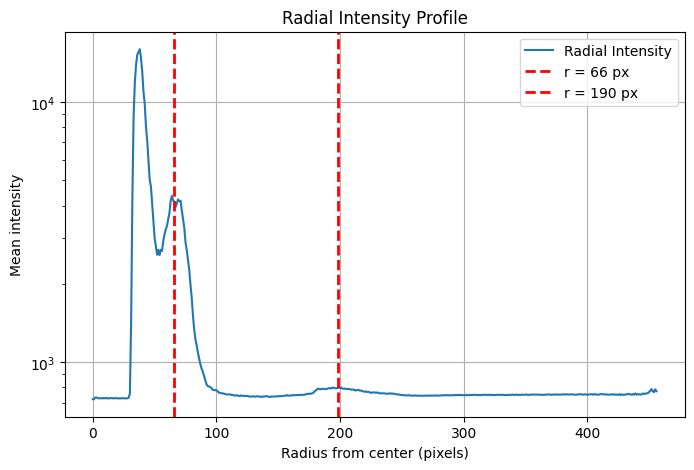

In [10]:
# radial intensity profile

ny, nx = frame.shape

y, x = np.indices(frame.shape)

r = np.sqrt((x - cx)**2 + (y - cy)**2)

r_int = r.astype(int)

radial_sum = np.bincount(
    r_int.ravel(),
    weights=frame.ravel()
)

radial_count = np.bincount(
    r_int.ravel()
)

radial_intensity = radial_sum / radial_count

radii = np.arange(len(radial_intensity))

plt.figure(figsize=(8, 5))
plt.semilogy(radii, radial_intensity, label="Radial Intensity")
#plt.plot(radii, radial_intensity,)

# Red vertical lines
plt.axvline(66, color="red", linestyle="--", linewidth=2, label="r = 66 px")
plt.axvline(198, color="red", linestyle="--", linewidth=2, label="r = 190 px")

plt.xlabel("Radius from center (pixels)")
plt.ylabel("Mean intensity")
plt.title("Radial Intensity Profile")
plt.grid()
plt.legend()

plt.show()

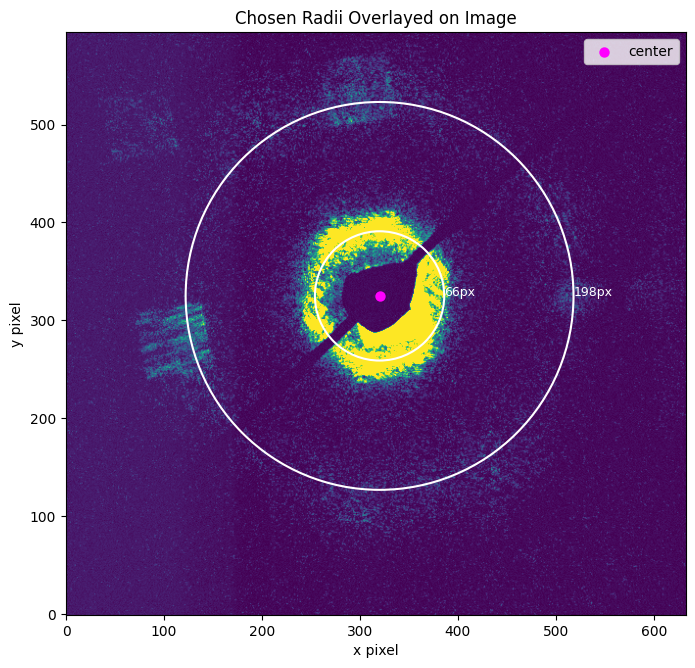

In [11]:
# choose radii and overlay circles on the image

from matplotlib.patches import Circle

chosen_radii = [66,198]  # change these radii in pixels

plt.figure(figsize=(8, 8))
ax = plt.gca()

ax.imshow(
    np.log10(frame + 1),
    origin="lower",
    cmap="viridis",
    vmin=np.percentile(display_img, 5),  
    vmax=np.percentile(display_img, 98)  
)

ax.scatter(
    cx, cy,
    s=30,
    marker="o",
    color="magenta",
    linewidths=2,
    label="center"
)

for rr in chosen_radii:
    circle = Circle(
        (cx, cy),
        rr,
        edgecolor="white",
        facecolor="none",
        linewidth=1.5
    )
    ax.add_patch(circle)
    ax.text(
        cx + rr,
        cy,
        f"{rr}px",
        color="white",
        fontsize=9
    )

#plt.colorbar(label="log10(intensity + 1)")
plt.title("Chosen Radii Overlayed on Image")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.legend()
plt.show()

In [13]:
# compare mean intensity of an outer ring to an inner ring

# choose image to measure
# this tries common variable names from the notebook
if "avg" in globals():
    img = avg.astype(float)

elif "average_image" in globals():
    img = average_image.astype(float)

elif "frame" in globals():
    img = frame.astype(float)

elif "images" in globals():
    # average over all frames
    img = np.mean(images, axis=0).astype(float)

elif "data" in globals():
    # squeeze handles shapes like (1, 1900, 600, 600)
    data_squeezed = np.squeeze(data)

    if data_squeezed.ndim == 3:
        img = np.mean(data_squeezed, axis=0).astype(float)
    elif data_squeezed.ndim == 2:
        img = data_squeezed.astype(float)
    else:
        raise ValueError(f"data has unexpected shape: {data_squeezed.shape}")

else:
    raise NameError("No image variable found. Define avg, average_image, frame, images, or data first.")

print("Using image shape:", img.shape)

Using image shape: (595, 633)


In [16]:
# ring intensity comparison

# center of rings
# change these if your center variables have different names
center_x = cx
center_y = cy

# choose radii in pixels
inner_radius = 66
outer_radius = 198

# choose ring thickness in pixels
ring_width = 5

# make radius map
ny, nx = img.shape
y, x = np.indices(img.shape)

r = np.sqrt((x - center_x)**2 + (y - center_y)**2)

# make ring masks
inner_ring = (
    (r >= inner_radius - ring_width / 2) &
    (r <= inner_radius + ring_width / 2)
)

outer_ring = (
    (r >= outer_radius - ring_width / 2) &
    (r <= outer_radius + ring_width / 2)
)

# get intensity values
inner_vals = img[inner_ring]
outer_vals = img[outer_ring]

# remove bad values
inner_vals = inner_vals[np.isfinite(inner_vals)]
outer_vals = outer_vals[np.isfinite(outer_vals)]

# optional: ignore zero-intensity masked/beamstop pixels
# uncomment these if needed
# inner_vals = inner_vals[inner_vals > 0]
# outer_vals = outer_vals[outer_vals > 0]

# calculate means
inner_mean = np.mean(inner_vals)
outer_mean = np.mean(outer_vals)

outer_percent_of_inner = 100 * outer_mean / inner_mean

print(f"Inner ring radius: {inner_radius} pixels")
print(f"Outer ring radius: {outer_radius} pixels")
print(f"Mean inner ring intensity: {inner_mean:.3f}")
print(f"Mean outer ring intensity: {outer_mean:.3f}")
print(f"Outer ring is {outer_percent_of_inner:.2f}% of the inner ring intensity")

Inner ring radius: 66 pixels
Outer ring radius: 198 pixels
Mean inner ring intensity: 4167.394
Mean outer ring intensity: 795.669
Outer ring is 19.09% of the inner ring intensity


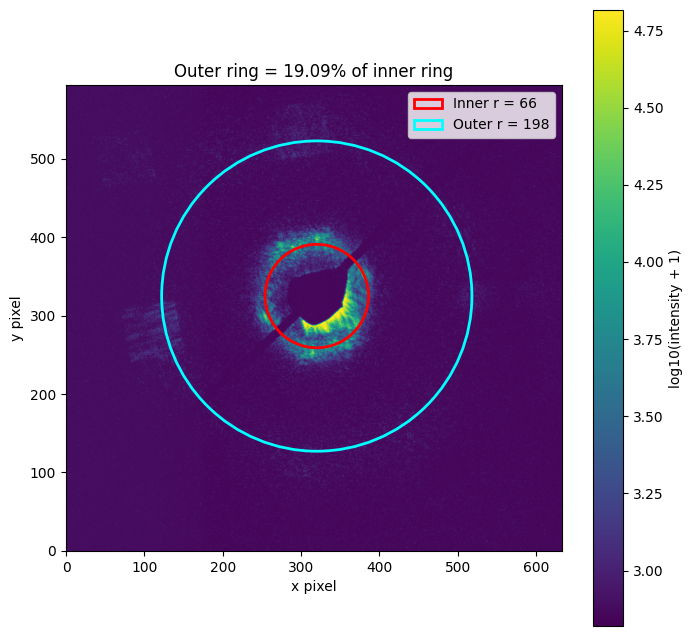

In [17]:
# plot selected rings

plt.figure(figsize=(8, 8))

plt.imshow(
    np.log10(img + 1),
    origin="lower",
    cmap="viridis"
)

ax = plt.gca()

inner_circle = plt.Circle(
    (center_x, center_y),
    inner_radius,
    color="red",
    fill=False,
    linewidth=2,
    label=f"Inner r = {inner_radius}"
)

outer_circle = plt.Circle(
    (center_x, center_y),
    outer_radius,
    color="cyan",
    fill=False,
    linewidth=2,
    label=f"Outer r = {outer_radius}"
)

ax.add_patch(inner_circle)
ax.add_patch(outer_circle)

plt.colorbar(label="log10(intensity + 1)")
plt.xlabel("x pixel")
plt.ylabel("y pixel")
plt.title(f"Outer ring = {outer_percent_of_inner:.2f}% of inner ring")
plt.legend()
plt.show()

Found ring radii in pixels:
Ring 0: radius = 37.00 pixels
Ring 1: radius = 66.00 pixels


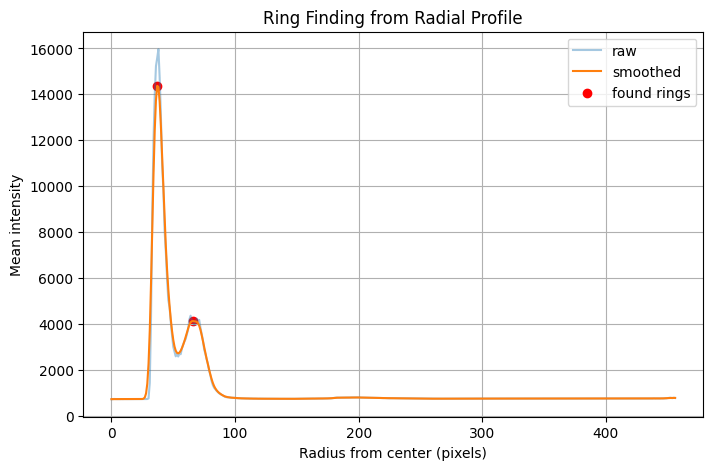

In [18]:
# find bright rings

smoothed_profile = gaussian_filter(radial_intensity, sigma=2)

min_radius = 5
max_radius = min(frame.shape) // 2

search_r = radii[min_radius:max_radius]
search_i = smoothed_profile[min_radius:max_radius]

peaks, props = find_peaks(
    search_i,
    prominence=np.nanmax(search_i) * 0.02,
    distance=5
)

ring_radii_pixels = search_r[peaks]

print("Found ring radii in pixels:")
for i, rr in enumerate(ring_radii_pixels):
    print(f"Ring {i}: radius = {rr:.2f} pixels")

plt.figure(figsize=(8, 5))

plt.plot(radii, radial_intensity, alpha=0.4, label="raw")
plt.plot(radii, smoothed_profile, label="smoothed")

plt.scatter(
    ring_radii_pixels,
    smoothed_profile[ring_radii_pixels.astype(int)],
    color="red",
    label="found rings"
)

ring_radii_pixels = [66,200]

plt.xlabel("Radius from center (pixels)")
plt.ylabel("Mean intensity")
plt.title("Ring Finding from Radial Profile")
plt.legend()
plt.grid()
plt.show()

In [88]:
# calculate q scale from ring radius

pixel_size_m = 55e-6          # detector pixel size in meters, change if needed
detector_distance_m = 0.50    # sample-to-detector distance in meters, change this
energy_eV = 778               # photon energy in eV, change this

# wavelength in meters
hc_eVm = 1.239841984e-6
wavelength_m = hc_eVm / energy_eV

print("Wavelength:", wavelength_m, "m")

Wavelength: 1.5936272287917738e-09 m


In [79]:
# convert radius to q

ring_radius_m = ring_radii_pixels * pixel_size_m

two_theta = np.arctan(ring_radius_m / detector_distance_m)

theta = two_theta / 2

q_m_inv = (4 * np.pi / wavelength_m) * np.sin(theta)

q_A_inv = q_m_inv * 1e-10

print("Ring momentum values:")
for i, (rr, qq) in enumerate(zip(ring_radii_pixels, q_A_inv)):
    print(f"Ring {i}: radius = {rr:.2f} pixels, q = {qq:.5f} 1/Å")

Ring momentum values:
Ring 0: radius = 37.00 pixels, q = 0.00160 1/Å
Ring 1: radius = 66.00 pixels, q = 0.00286 1/Å


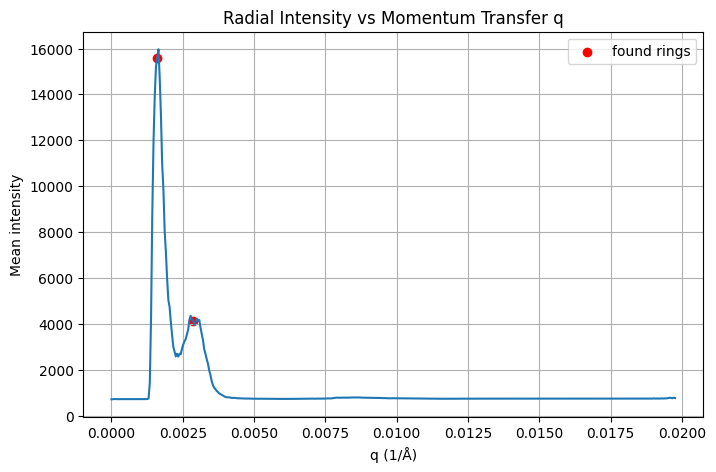

In [80]:
# plot intensity vs q

radius_m = radii * pixel_size_m
two_theta_all = np.arctan(radius_m / detector_distance_m)
theta_all = two_theta_all / 2

q_all_m_inv = (4 * np.pi / wavelength_m) * np.sin(theta_all)
q_all_A_inv = q_all_m_inv * 1e-10

plt.figure(figsize=(8, 5))

plt.plot(q_all_A_inv, radial_intensity)

plt.scatter(
    q_A_inv,
    radial_intensity[ring_radii_pixels.astype(int)],
    color="red",
    label="found rings"
)

plt.xlabel("q (1/Å)")
plt.ylabel("Mean intensity")
plt.title("Radial Intensity vs Momentum Transfer q")
plt.legend()
plt.grid()
plt.show()

In [81]:
# calculate real-space length scale

length_A = 2 * np.pi / q_A_inv
length_nm = length_A / 10

print("Ring length scales:")
for i, (qq, ll_A, ll_nm) in enumerate(zip(q_A_inv, length_A, length_nm)):
    print(
        f"Ring {i}: q = {qq:.5f} 1/Å, "
        f"length = {ll_A:.2f} Å = {ll_nm:.2f} nm"
    )

Ring length scales:
Ring 0: q = 0.00160 1/Å, length = 3915.57 Å = 391.56 nm
Ring 1: q = 0.00286 1/Å, length = 2195.12 Å = 219.51 nm
